# 03 XGBoost Loan Approval Classification

## Project Overview

This project develops a complete machine learning workflow for predicting whether a loan application will be approved or rejected. The main algorithm is XGBoost, an optimized gradient-boosting framework that combines multiple weak decision trees into a strong predictive model.

The notebook includes:

- Business and problem understanding.
- Robust data ingestion and validation.
- Data cleaning and exploratory analysis.
- Feature preprocessing using reusable pipelines.
- Baseline XGBoost development.
- Hyperparameter optimization.
- Comparison with multiple classification algorithms.
- Threshold analysis.
- Feature importance interpretation.
- A final reusable XGBoost training function with editable parameters.
- Serialization of the complete production pipeline.

## Project Metadata

- Project name: `03_XGBoost_LoanApproval`
- Dataset: `loan_approval_dataset.csv`
- Target variable: `loan_status`
- Positive class: `Approved`
- Primary algorithm: XGBoost Classifier
- Primary evaluation metric: ROC-AUC
- Deployment-ready artifact: complete preprocessing and model pipeline

In [1]:
from pathlib import Path
import time
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)

from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TEST_SIZE = 0.20

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

print("Environment setup completed successfully.")

Environment setup completed successfully.


## Phase 1: Business Understanding and Problem Definition

Loan approval is a binary classification problem in which a financial institution evaluates an applicant's financial profile and predicts whether the application should be approved or rejected.

A useful model can support:

- Faster preliminary screening.
- Consistent treatment of applications.
- Better allocation of manual review resources.
- Improved identification of applicants who satisfy lending requirements.
- Transparent comparison between traditional and ensemble classifiers.

The target classes have different operational implications:

- A false positive occurs when the model predicts approval for an application that belongs to the rejected class. In a real lending system, this may expose the institution to avoidable credit risk.
- A false negative occurs when the model predicts rejection for an application that belongs to the approved class. This may cause a missed business opportunity and an unsatisfactory customer experience.

The relative importance of these errors depends on the organization's risk policy. Therefore, the notebook reports multiple metrics rather than relying only on accuracy.

XGBoost is selected as the primary model because it:

- Captures nonlinear relationships.
- Models interactions between applicant attributes.
- Uses sequential boosting to correct previous errors.
- Includes regularization and row or feature subsampling.
- Usually performs strongly on structured tabular datasets.

In [2]:
business_definition = {
    "problem_type": "Binary classification",
    "target": "loan_status",
    "positive_class": "Approved",
    "primary_model": "XGBoost Classifier",
    "primary_metric": "ROC-AUC",
    "supporting_metrics": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
    ],
}

business_definition

{'problem_type': 'Binary classification',
 'target': 'loan_status',
 'positive_class': 'Approved',
 'primary_model': 'XGBoost Classifier',
 'primary_metric': 'ROC-AUC',
 'supporting_metrics': ['Accuracy', 'Precision', 'Recall', 'F1-score']}

## Phase 2: Data Ingestion

The ingestion process must work whether the notebook is executed from the repository root, the `notebooks` directory, or another environment. Several candidate paths are checked before raising an informative error.

Initial validation includes:

- Dataset dimensions.
- Sample records.
- Column data types.
- Memory usage.
- Raw column-name inspection.

The original dataset contains leading spaces in several column names and categorical values. These spaces must be removed before reliable feature selection and preprocessing.

In [3]:
candidate_data_paths = [
    Path("../data/raw/loan_approval_dataset.csv"),
    Path("data/raw/loan_approval_dataset.csv"),
    Path("loan_approval_dataset.csv"),
    Path("/mnt/data/loan_approval_dataset.csv"),
]

data_path = next(
    (path for path in candidate_data_paths if path.exists()),
    None,
)

if data_path is None:
    checked_paths = "\n".join(
        str(path.resolve()) for path in candidate_data_paths
    )
    raise FileNotFoundError(
        "The loan approval dataset was not found. "
        f"Checked the following paths:\n{checked_paths}"
    )

df = pd.read_csv(data_path)

print(f"Dataset path: {data_path.resolve()}")
print(f"Dataset dimensions: {df.shape[0]:,} rows and {df.shape[1]:,} columns")
print(f"Raw columns: {df.columns.tolist()}")

display(df.head())

print("\nDataset information:")
df.info()

Dataset path: C:\Users\soham\Desktop\ahmed\NTI-ML\03_XGBoost_LoanApproval\data\raw\loan_approval_dataset.csv
Dataset dimensions: 4,269 rows and 13 columns
Raw columns: ['loan_id', ' no_of_dependents', ' education', ' self_employed', ' income_annum', ' loan_amount', ' loan_term', ' cibil_score', ' residential_assets_value', ' commercial_assets_value', ' luxury_assets_value', ' bank_asset_value', ' loan_status']


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected



Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   loan_id                    4269 non-null   int64
 1    no_of_dependents          4269 non-null   int64
 2    education                 4269 non-null   str  
 3    self_employed             4269 non-null   str  
 4    income_annum              4269 non-null   int64
 5    loan_amount               4269 non-null   int64
 6    loan_term                 4269 non-null   int64
 7    cibil_score               4269 non-null   int64
 8    residential_assets_value  4269 non-null   int64
 9    commercial_assets_value   4269 non-null   int64
 10   luxury_assets_value       4269 non-null   int64
 11   bank_asset_value          4269 non-null   int64
 12   loan_status               4269 non-null   str  
dtypes: int64(10), str(3)
memory usage: 531.6 KB


## Phase 3: Data Cleaning and Quality Assessment

The cleaning stage standardizes the schema and checks whether the observations are suitable for modeling.

The main operations are:

- Strip leading and trailing spaces from column names.
- Strip leading and trailing spaces from categorical values.
- Detect exact duplicate rows.
- Detect duplicated identifiers.
- Inspect missing values.
- Validate the target classes.
- Remove `loan_id`, because it is an administrative identifier rather than a behavioral predictor.

Removing identifiers reduces the risk that a model memorizes record order or learns patterns that do not generalize to future applications.

In [4]:
clean_df = df.copy()

clean_df.columns = clean_df.columns.str.strip()

object_columns = clean_df.select_dtypes(include="object").columns
for column in object_columns:
    clean_df[column] = clean_df[column].str.strip()

print(f"Exact duplicate rows: {clean_df.duplicated().sum():,}")
print(
    "Duplicated loan IDs: "
    f"{clean_df['loan_id'].duplicated().sum():,}"
)

missing_summary = (
    clean_df.isna()
    .sum()
    .to_frame("missing_count")
    .assign(
        missing_percentage=lambda table:
        table["missing_count"] / len(clean_df) * 100
    )
)

display(missing_summary)

target_column = "loan_status"

if target_column not in clean_df.columns:
    raise KeyError(
        f"Target column '{target_column}' was not found."
    )

expected_target_values = {"Approved", "Rejected"}
observed_target_values = set(clean_df[target_column].unique())

if observed_target_values != expected_target_values:
    raise ValueError(
        "Unexpected target values were detected. "
        f"Observed values: {observed_target_values}"
    )

clean_df = clean_df.drop(columns=["loan_id"]).copy()

print(f"Cleaned dataset dimensions: {clean_df.shape}")
print("\nCleaned schema:")
print(clean_df.dtypes)

Exact duplicate rows: 0
Duplicated loan IDs: 0


,missing_count,missing_percentage
loan_id,0,0.0000
no_of_dependents,0,0.0000
education,0,0.0000
self_employed,0,0.0000
income_annum,0,0.0000
loan_amount,0,0.0000
loan_term,0,0.0000
cibil_score,0,0.0000
residential_assets_value,0,0.0000
commercial_assets_value,0,0.0000


Cleaned dataset dimensions: (4269, 12)

Cleaned schema:
no_of_dependents            int64
education                     str
self_employed                 str
income_annum                int64
loan_amount                 int64
loan_term                   int64
cibil_score                 int64
residential_assets_value    int64
commercial_assets_value     int64
luxury_assets_value         int64
bank_asset_value            int64
loan_status                   str
dtype: object


## Phase 4: Exploratory Data Analysis

Exploratory analysis describes the class balance and the behavior of the input variables before model training.

The analysis includes:

- Target counts and percentages.
- Numerical descriptive statistics.
- Categorical frequency distributions.
- Approval rates by categorical group.
- Numerical averages by application status.
- Numerical correlation analysis.

The results are descriptive and should not be interpreted as causal relationships.

In [5]:
target_counts = clean_df[target_column].value_counts()
target_percentages = (
    clean_df[target_column]
    .value_counts(normalize=True)
    .mul(100)
)

target_distribution = pd.DataFrame({
    "count": target_counts,
    "percentage": target_percentages,
})

display(target_distribution)

print("\nNumerical summary statistics:")
display(clean_df.describe().T)

,count,percentage
loan_status,,
Approved,2656,62.2160
Rejected,1613,37.7840



Numerical summary statistics:


,count,mean,std,min,25%,50%,75%,max
no_of_dependents,"4,269.0000",2.4987,1.6959,0.0000,1.0000,3.0000,4.0000,5.0000
income_annum,"4,269.0000","5,059,123.9166","2,806,839.8318","200,000.0000","2,700,000.0000","5,100,000.0000","7,500,000.0000","9,900,000.0000"
loan_amount,"4,269.0000","15,133,450.4568","9,043,362.9848","300,000.0000","7,700,000.0000","14,500,000.0000","21,500,000.0000","39,500,000.0000"
loan_term,"4,269.0000",10.9004,5.7092,2.0000,6.0000,10.0000,16.0000,20.0000
cibil_score,"4,269.0000",599.9361,172.4304,300.0000,453.0000,600.0000,748.0000,900.0000
residential_assets_value,"4,269.0000","7,472,616.5378","6,503,636.5877","-100,000.0000","2,200,000.0000","5,600,000.0000","11,300,000.0000","29,100,000.0000"
commercial_assets_value,"4,269.0000","4,973,155.3057","4,388,966.0896",0.0000,"1,300,000.0000","3,700,000.0000","7,600,000.0000","19,400,000.0000"
luxury_assets_value,"4,269.0000","15,126,305.9264","9,103,753.6653","300,000.0000","7,500,000.0000","14,600,000.0000","21,700,000.0000","39,200,000.0000"
bank_asset_value,"4,269.0000","4,976,692.4338","3,250,185.3057",0.0000,"2,300,000.0000","4,600,000.0000","7,100,000.0000","14,700,000.0000"


### Target Class Distribution

The target distribution indicates whether one outcome is substantially more common than the other. Stratified splitting will preserve these proportions in the training and testing subsets.

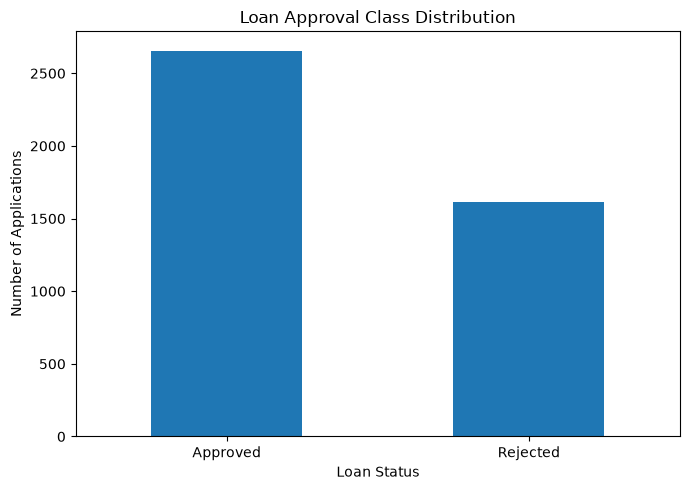

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))

target_counts.plot(
    kind="bar",
    ax=ax,
)

ax.set_title("Loan Approval Class Distribution")
ax.set_xlabel("Loan Status")
ax.set_ylabel("Number of Applications")
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

### Categorical Feature Analysis

The categorical variables are evaluated using frequency tables and group-level approval rates. Since the target will later be encoded as one for approved and zero for rejected, the mean target value within each category represents the observed approval rate.

In [7]:
eda_df = clean_df.copy()
eda_df["loan_status_binary"] = (
    eda_df[target_column]
    .map({"Rejected": 0, "Approved": 1})
)

categorical_columns = (
    clean_df
    .select_dtypes(include=["object", "category"])
    .columns
    .drop(target_column)
    .tolist()
)

for column in categorical_columns:
    print(f"\nFrequency distribution for {column}:")
    display(
        clean_df[column]
        .value_counts(dropna=False)
        .to_frame("count")
        .assign(
            percentage=lambda table:
            table["count"] / len(clean_df) * 100
        )
    )

    print(f"Approval rate by {column}:")
    display(
        eda_df.groupby(column)["loan_status_binary"]
        .agg(application_count="size", approval_rate="mean")
        .assign(
            approval_rate=lambda table:
            table["approval_rate"] * 100
        )
        .sort_values("approval_rate", ascending=False)
    )


Frequency distribution for education:


,count,percentage
education,,
Graduate,2144,50.2225
Not Graduate,2125,49.7775


Approval rate by education:


,application_count,approval_rate
education,,
Graduate,2144,62.4534
Not Graduate,2125,61.9765



Frequency distribution for self_employed:


,count,percentage
self_employed,,
Yes,2150,50.3631
No,2119,49.6369


Approval rate by self_employed:


,application_count,approval_rate
self_employed,,
Yes,2150,62.2326
No,2119,62.1992


### Numerical Feature Comparison by Loan Status

Comparing feature averages between approved and rejected applications provides an initial indication of potentially informative variables. XGBoost can still identify nonlinear thresholds and feature interactions that are not visible from averages alone.

In [8]:
numerical_columns = (
    clean_df
    .select_dtypes(include=np.number)
    .columns
    .tolist()
)

numerical_status_comparison = (
    clean_df.groupby(target_column)[numerical_columns]
    .mean()
    .T
)

numerical_status_comparison["absolute_difference"] = (
    numerical_status_comparison["Approved"]
    - numerical_status_comparison["Rejected"]
).abs()

display(
    numerical_status_comparison.sort_values(
        "absolute_difference",
        ascending=False,
    )
)

loan_status,Approved,Rejected,absolute_difference
loan_amount,"15,247,251.5060","14,946,063.2362","301,188.2698"
luxury_assets_value,"15,016,603.9157","15,306,943.5834","290,339.6677"
residential_assets_value,"7,399,811.7470","7,592,498.4501","192,686.7031"
income_annum,"5,025,903.6145","5,113,825.1705","87,921.5560"
commercial_assets_value,"5,001,355.4217","4,926,720.3968","74,635.0249"
bank_asset_value,"4,959,525.6024","5,004,959.7024","45,434.1000"
cibil_score,703.4620,429.4681,273.9939
loan_term,10.3976,11.7285,1.3309
no_of_dependents,2.4748,2.5381,0.0634


### Correlation Analysis

The correlation matrix measures linear association among numerical features. Strong correlation does not necessarily require feature removal for tree-based models, but it can reveal redundant financial variables and provide useful context for later interpretation.

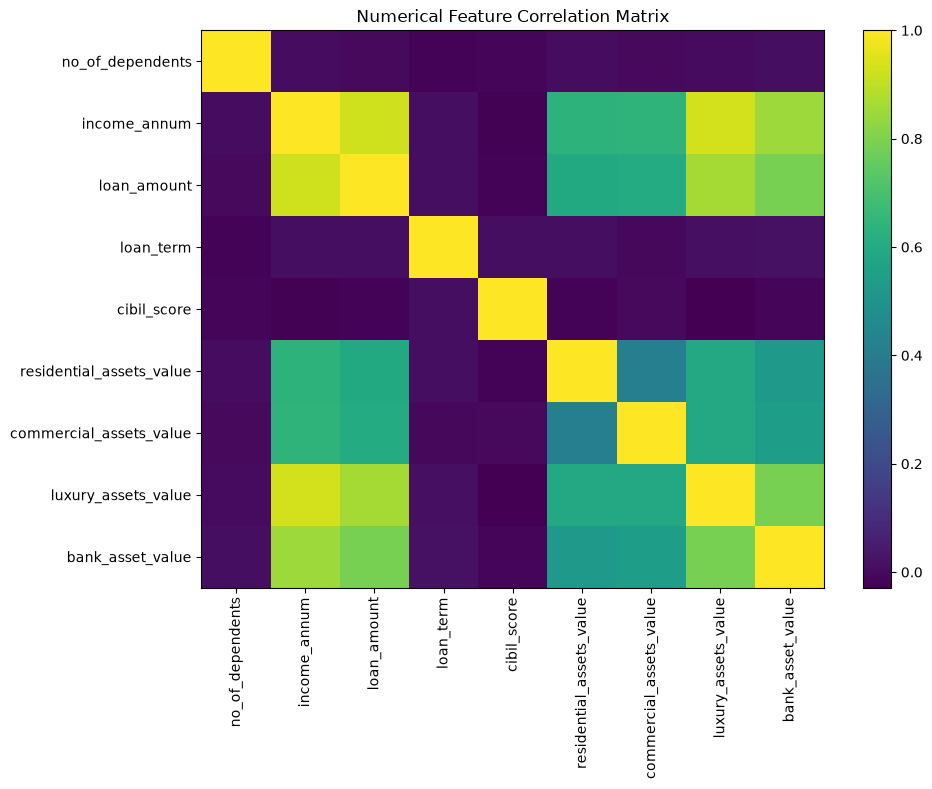

In [9]:
correlation_matrix = clean_df[numerical_columns].corr()

fig, ax = plt.subplots(figsize=(10, 8))
image = ax.imshow(correlation_matrix, aspect="auto")

ax.set_xticks(range(len(correlation_matrix.columns)))
ax.set_xticklabels(
    correlation_matrix.columns,
    rotation=90,
)
ax.set_yticks(range(len(correlation_matrix.index)))
ax.set_yticklabels(correlation_matrix.index)
ax.set_title("Numerical Feature Correlation Matrix")

fig.colorbar(image, ax=ax)
plt.tight_layout()
plt.show()

## Phase 5: Feature and Target Preparation

The target is encoded as:

- `Approved = 1`
- `Rejected = 0`

The predictors contain numerical and categorical variables. A `ColumnTransformer` applies:

- Standard scaling to numerical features.
- One-hot encoding to categorical features.

Although tree-based models do not require scaling, the shared preprocessing pipeline allows all comparison models to receive the same transformed dataset. This makes the comparison reproducible and prevents data leakage because preprocessing is fitted only on the training data inside each pipeline.

In [10]:
X = clean_df.drop(columns=[target_column]).copy()

y = (
    clean_df[target_column]
    .map({"Rejected": 0, "Approved": 1})
    .astype(int)
)

numerical_features = (
    X.select_dtypes(include=np.number).columns.tolist()
)
categorical_features = (
    X.select_dtypes(exclude=np.number).columns.tolist()
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            StandardScaler(),
            numerical_features,
        ),
        (
            "categorical",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore",
                sparse_output=False,
            ),
            categorical_features,
        ),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

print(f"Numerical features: {numerical_features}")
print(f"Categorical features: {categorical_features}")
print("\nEncoded target distribution:")
display(y.value_counts().sort_index().to_frame("count"))

Numerical features: ['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']
Categorical features: ['education', 'self_employed']

Encoded target distribution:


,count
loan_status,
0,1613
1,2656


## Phase 6: Stratified Train-Test Split

The dataset is divided into an 80 percent training subset and a 20 percent test subset. Stratification preserves the class distribution in both sets.

The test set remains isolated until final model evaluation. Hyperparameter tuning is performed only through cross-validation on the training data.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

split_summary = pd.DataFrame({
    "training_count": y_train.value_counts().sort_index(),
    "testing_count": y_test.value_counts().sort_index(),
    "training_percentage": (
        y_train.value_counts(normalize=True).sort_index() * 100
    ),
    "testing_percentage": (
        y_test.value_counts(normalize=True).sort_index() * 100
    ),
})

split_summary.index = ["Rejected", "Approved"]

display(split_summary)

print(f"Training shape: {X_train.shape}")
print(f"Testing shape: {X_test.shape}")

,training_count,testing_count,training_percentage,testing_percentage
Rejected,1290,323,37.7745,37.8220
Approved,2125,531,62.2255,62.1780


Training shape: (3415, 11)
Testing shape: (854, 11)


## Phase 7: Baseline XGBoost Model

The baseline model establishes a reference before hyperparameter tuning. Important XGBoost parameters include:

- `n_estimators`: number of boosting trees.
- `learning_rate`: contribution of each new tree.
- `max_depth`: maximum tree depth.
- `subsample`: fraction of training rows used by each tree.
- `colsample_bytree`: fraction of features sampled by each tree.
- `min_child_weight`: minimum weighted observation requirement in a child node.
- `gamma`: minimum loss reduction required to create a split.
- `reg_alpha`: L1 regularization.
- `reg_lambda`: L2 regularization.

The model is wrapped inside a pipeline so that preprocessing and prediction remain a single reproducible object.

In [12]:
baseline_xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        (
            "model",
            XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                n_estimators=100,
                learning_rate=0.10,
                max_depth=3,
                subsample=1.0,
                colsample_bytree=1.0,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ]
)

baseline_start_time = time.perf_counter()
baseline_xgb_pipeline.fit(X_train, y_train)
baseline_training_time = (
    time.perf_counter() - baseline_start_time
)

baseline_predictions = baseline_xgb_pipeline.predict(X_test)
baseline_probabilities = (
    baseline_xgb_pipeline.predict_proba(X_test)[:, 1]
)

baseline_xgb_metrics = {
    "accuracy": accuracy_score(
        y_test,
        baseline_predictions,
    ),
    "precision": precision_score(
        y_test,
        baseline_predictions,
        zero_division=0,
    ),
    "recall": recall_score(
        y_test,
        baseline_predictions,
        zero_division=0,
    ),
    "f1_score": f1_score(
        y_test,
        baseline_predictions,
        zero_division=0,
    ),
    "roc_auc": roc_auc_score(
        y_test,
        baseline_probabilities,
    ),
    "training_time_seconds": baseline_training_time,
}

display(
    pd.Series(
        baseline_xgb_metrics,
        name="Baseline XGBoost",
    ).to_frame()
)

,Baseline XGBoost
accuracy,0.9824
precision,0.9813
recall,0.9906
f1_score,0.9859
roc_auc,0.9984
training_time_seconds,0.1464


## Phase 8: XGBoost Hyperparameter Tuning

GridSearchCV evaluates combinations of selected hyperparameters using stratified 5-fold cross-validation.

The search uses ROC-AUC because it measures probability-ranking quality across thresholds. The search space is intentionally controlled to balance computational cost and model quality. A larger production search may include additional values or use randomized or Bayesian optimization.

In [13]:
xgb_tuning_pipeline = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        (
            "model",
            XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ]
)

xgb_param_grid = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.03, 0.10],
    "model__max_depth": [3, 5],
    "model__subsample": [0.80, 1.00],
    "model__colsample_bytree": [0.80, 1.00],
    "model__min_child_weight": [1],
    "model__gamma": [0.0],
    "model__reg_alpha": [0.0],
    "model__reg_lambda": [1.0],
}

cross_validation = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

xgb_grid_search = GridSearchCV(
    estimator=xgb_tuning_pipeline,
    param_grid=xgb_param_grid,
    scoring="roc_auc",
    cv=cross_validation,
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
)

tuning_start_time = time.perf_counter()
xgb_grid_search.fit(X_train, y_train)
tuning_time = time.perf_counter() - tuning_start_time

best_xgb_pipeline = xgb_grid_search.best_estimator_

print("Best XGBoost parameters:")
print(xgb_grid_search.best_params_)
print(
    f"Best cross-validation ROC-AUC: "
    f"{xgb_grid_search.best_score_:.4f}"
)
print(f"Total tuning time: {tuning_time:.2f} seconds")

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best XGBoost parameters:
{'model__colsample_bytree': 1.0, 'model__gamma': 0.0, 'model__learning_rate': 0.03, 'model__max_depth': 5, 'model__min_child_weight': 1, 'model__n_estimators': 200, 'model__reg_alpha': 0.0, 'model__reg_lambda': 1.0, 'model__subsample': 0.8}
Best cross-validation ROC-AUC: 0.9982
Total tuning time: 47.40 seconds


### Cross-Validation Search Results

The ranked search table compares mean training and validation ROC-AUC. A very large gap between the two scores may indicate overfitting, even when validation performance is strong.

In [14]:
xgb_cv_results = pd.DataFrame(
    xgb_grid_search.cv_results_
)

xgb_cv_summary = xgb_cv_results[
    [
        "rank_test_score",
        "mean_train_score",
        "std_train_score",
        "mean_test_score",
        "std_test_score",
        "mean_fit_time",
        "param_model__n_estimators",
        "param_model__learning_rate",
        "param_model__max_depth",
        "param_model__subsample",
        "param_model__colsample_bytree",
    ]
].sort_values("rank_test_score")

display(xgb_cv_summary.head(10))

,rank_test_score,mean_train_score,std_train_score,mean_test_score,std_test_score,mean_fit_time,param_model__n_estimators,param_model__learning_rate,param_model__max_depth,param_model__subsample,param_model__colsample_bytree
22,1,0.9999,0.0000,0.9982,0.0009,3.4229,200,0.0300,5,0.8000,1.0000
28,2,1.0000,0.0000,0.9981,0.0012,1.3210,100,0.1000,5,0.8000,1.0000
24,3,0.9997,0.0001,0.9981,0.0009,1.2644,100,0.1000,3,0.8000,1.0000
25,4,0.9997,0.0001,0.9981,0.0009,1.2198,100,0.1000,3,1.0000,1.0000
12,5,1.0000,0.0000,0.9980,0.0010,0.6015,100,0.1000,5,0.8000,0.8000
6,6,0.9999,0.0000,0.9980,0.0010,1.1831,200,0.0300,5,0.8000,0.8000
23,7,0.9999,0.0000,0.9980,0.0012,2.2343,200,0.0300,5,1.0000,1.0000
7,8,0.9999,0.0000,0.9979,0.0011,0.8409,200,0.0300,5,1.0000,0.8000
8,9,0.9996,0.0001,0.9979,0.0007,0.4570,100,0.1000,3,0.8000,0.8000
19,10,0.9992,0.0001,0.9979,0.0008,2.3010,200,0.0300,3,1.0000,1.0000


## Phase 9: Tuned XGBoost Evaluation

The optimized pipeline is evaluated on the untouched test set using:

- Accuracy.
- Precision.
- Recall.
- F1-score.
- ROC-AUC.
- Classification report.
- Confusion matrix.
- ROC curve.

The positive class is `Approved`. Therefore, positive-class precision measures how frequently predicted approvals are actually approved in the dataset, while recall measures the proportion of approved applications identified by the model.

In [15]:
optimized_start_time = time.perf_counter()

optimized_predictions = best_xgb_pipeline.predict(X_test)
optimized_probabilities = (
    best_xgb_pipeline.predict_proba(X_test)[:, 1]
)

optimized_prediction_time = (
    time.perf_counter() - optimized_start_time
)

optimized_xgb_metrics = {
    "accuracy": accuracy_score(
        y_test,
        optimized_predictions,
    ),
    "precision": precision_score(
        y_test,
        optimized_predictions,
        zero_division=0,
    ),
    "recall": recall_score(
        y_test,
        optimized_predictions,
        zero_division=0,
    ),
    "f1_score": f1_score(
        y_test,
        optimized_predictions,
        zero_division=0,
    ),
    "roc_auc": roc_auc_score(
        y_test,
        optimized_probabilities,
    ),
    "prediction_time_seconds": optimized_prediction_time,
}

xgb_before_after = pd.DataFrame({
    "Baseline XGBoost": pd.Series(baseline_xgb_metrics),
    "Tuned XGBoost": pd.Series(optimized_xgb_metrics),
})

display(xgb_before_after)

print("Tuned XGBoost classification report:")
print(
    classification_report(
        y_test,
        optimized_predictions,
        target_names=["Rejected", "Approved"],
        digits=4,
    )
)

,Baseline XGBoost,Tuned XGBoost
accuracy,0.9824,0.9836
f1_score,0.9859,0.9869
precision,0.9813,0.9832
prediction_time_seconds,NaN,0.1203
recall,0.9906,0.9906
roc_auc,0.9984,0.9987
training_time_seconds,0.1464,NaN


Tuned XGBoost classification report:
              precision    recall  f1-score   support

    Rejected     0.9843    0.9721    0.9782       323
    Approved     0.9832    0.9906    0.9869       531

    accuracy                         0.9836       854
   macro avg     0.9838    0.9814    0.9825       854
weighted avg     0.9836    0.9836    0.9836       854



### Tuned XGBoost Confusion Matrix

The confusion matrix reports the number of correctly and incorrectly classified applications for each outcome.

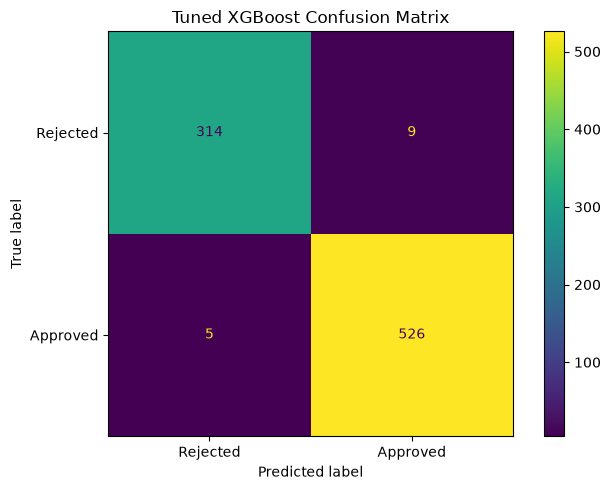

In [16]:
xgb_confusion_matrix = confusion_matrix(
    y_test,
    optimized_predictions,
)

fig, ax = plt.subplots(figsize=(7, 5))

ConfusionMatrixDisplay(
    confusion_matrix=xgb_confusion_matrix,
    display_labels=["Rejected", "Approved"],
).plot(
    ax=ax,
    values_format="d",
)

ax.set_title("Tuned XGBoost Confusion Matrix")

plt.tight_layout()
plt.show()

### Tuned XGBoost ROC Curve

The ROC curve evaluates sensitivity against the false-positive rate over multiple probability thresholds. A curve closer to the upper-left corner indicates stronger discrimination.

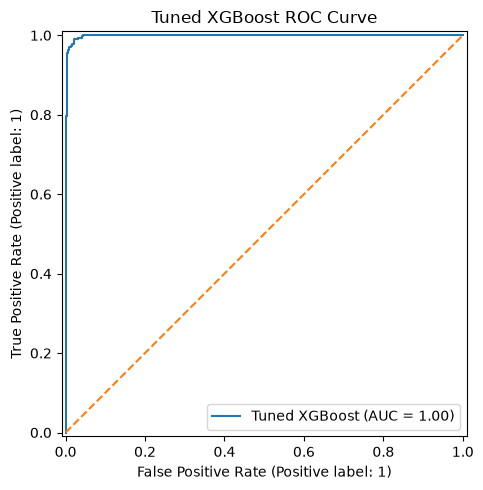

In [17]:
fig, ax = plt.subplots(figsize=(7, 5))

RocCurveDisplay.from_predictions(
    y_test,
    optimized_probabilities,
    name="Tuned XGBoost",
    ax=ax,
)

ax.plot([0, 1], [0, 1], linestyle="--")
ax.set_title("Tuned XGBoost ROC Curve")

plt.tight_layout()
plt.show()

## Phase 10: Classification Model Comparison

A useful model comparison must apply the same train-test split and equivalent preprocessing to every algorithm.

The following classifiers are evaluated:

- Logistic Regression.
- Decision Tree.
- Random Forest.
- K-Nearest Neighbors.
- Support Vector Machine.
- Gradient Boosting.
- Baseline XGBoost.
- Tuned XGBoost.

Each model is wrapped in its own pipeline. The comparison reports test-set metrics and training time. The goal is not to assume that XGBoost must win, but to determine which model provides the strongest balance of discrimination, classification quality, computational cost, and interpretability.

In [18]:
comparison_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE,
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "K-Nearest Neighbors": KNeighborsClassifier(
        n_neighbors=7,
    ),
    "Support Vector Machine": SVC(
        kernel="rbf",
        probability=True,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=RANDOM_STATE,
    ),
    "Baseline XGBoost": XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        n_estimators=100,
        learning_rate=0.10,
        max_depth=3,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
}

comparison_results = []
trained_comparison_pipelines = {}

for model_name, model in comparison_models.items():
    pipeline = Pipeline(
        steps=[
            ("preprocessor", clone(preprocessor)),
            ("model", model),
        ]
    )

    start_time = time.perf_counter()
    pipeline.fit(X_train, y_train)
    training_time = time.perf_counter() - start_time

    predictions = pipeline.predict(X_test)
    probabilities = pipeline.predict_proba(X_test)[:, 1]

    comparison_results.append({
        "model": model_name,
        "accuracy": accuracy_score(y_test, predictions),
        "precision": precision_score(
            y_test,
            predictions,
            zero_division=0,
        ),
        "recall": recall_score(
            y_test,
            predictions,
            zero_division=0,
        ),
        "f1_score": f1_score(
            y_test,
            predictions,
            zero_division=0,
        ),
        "roc_auc": roc_auc_score(
            y_test,
            probabilities,
        ),
        "training_time_seconds": training_time,
    })

    trained_comparison_pipelines[model_name] = pipeline

comparison_results.append({
    "model": "Tuned XGBoost",
    "accuracy": optimized_xgb_metrics["accuracy"],
    "precision": optimized_xgb_metrics["precision"],
    "recall": optimized_xgb_metrics["recall"],
    "f1_score": optimized_xgb_metrics["f1_score"],
    "roc_auc": optimized_xgb_metrics["roc_auc"],
    "training_time_seconds": tuning_time,
})

model_comparison_df = (
    pd.DataFrame(comparison_results)
    .sort_values(
        by=["roc_auc", "f1_score"],
        ascending=False,
    )
    .reset_index(drop=True)
)

display(model_comparison_df)

,model,accuracy,precision,recall,f1_score,roc_auc,training_time_seconds
0,Random Forest,0.9824,0.9850,0.9868,0.9859,0.9989,1.8368
1,Tuned XGBoost,0.9836,0.9832,0.9906,0.9869,0.9987,47.4006
2,Baseline XGBoost,0.9824,0.9813,0.9906,0.9859,0.9984,0.1458
3,Gradient Boosting,0.9824,0.9831,0.9887,0.9859,0.9976,0.7965
4,Decision Tree,0.9754,0.9904,0.9699,0.9800,0.9937,0.1708
5,Support Vector Machine,0.9403,0.9688,0.9341,0.9511,0.9877,1.1227
6,Logistic Regression,0.9145,0.9210,0.9435,0.9321,0.9726,0.1431
7,K-Nearest Neighbors,0.9098,0.9142,0.9435,0.9286,0.9699,0.0255


### Visual Comparison of Classification Models

ROC-AUC is used as the primary ranking metric, while F1-score is displayed separately to show threshold-dependent classification quality. Models with similar ROC-AUC may still produce different precision-recall trade-offs at the default threshold.

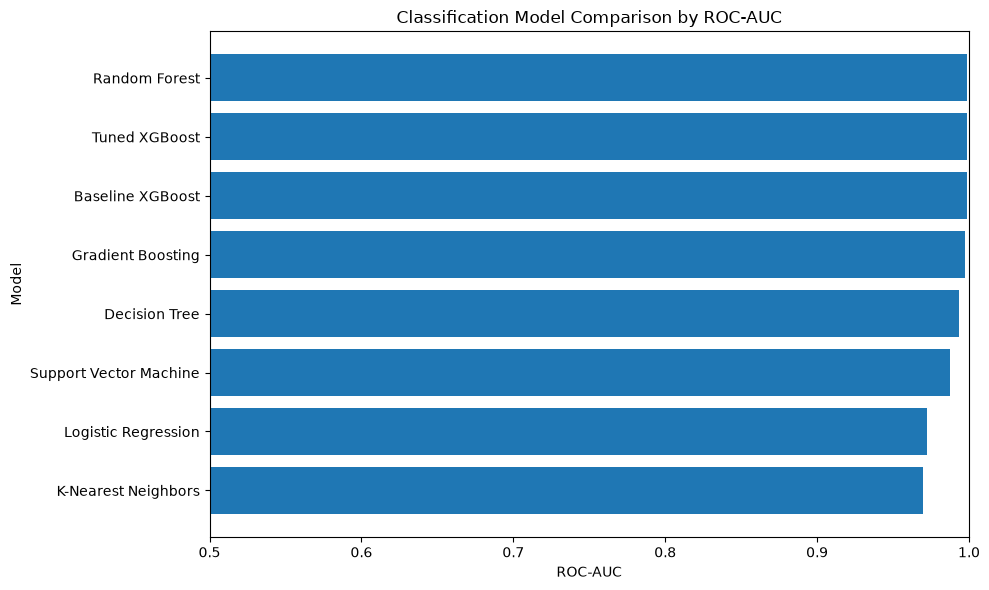

In [19]:
roc_auc_plot_data = (
    model_comparison_df
    .sort_values("roc_auc", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    roc_auc_plot_data["model"],
    roc_auc_plot_data["roc_auc"],
)

ax.set_title("Classification Model Comparison by ROC-AUC")
ax.set_xlabel("ROC-AUC")
ax.set_ylabel("Model")
ax.set_xlim(0.50, 1.00)

plt.tight_layout()
plt.show()

### Best Model Selection

The best model is selected according to ROC-AUC, with F1-score used as a secondary ranking criterion. This rule prioritizes probability discrimination while still recognizing threshold-based classification quality.

In [20]:
best_comparison_row = model_comparison_df.iloc[0]

print("Best model according to the comparison:")
display(best_comparison_row.to_frame("value"))

if best_comparison_row["model"] == "Tuned XGBoost":
    final_pipeline = best_xgb_pipeline
else:
    final_pipeline = trained_comparison_pipelines[
        best_comparison_row["model"]
    ]

print(
    f"Selected final pipeline: "
    f"{best_comparison_row['model']}"
)

Best model according to the comparison:


,value
model,Random Forest
accuracy,0.9824
precision,0.9850
recall,0.9868
f1_score,0.9859
roc_auc,0.9989
training_time_seconds,1.8368


Selected final pipeline: Random Forest


## Phase 11: Classification Threshold Analysis

The default threshold of 0.50 may not reflect the organization's risk policy. The following analysis evaluates different thresholds for the tuned XGBoost model.

Increasing the threshold generally makes approval predictions more conservative. This may increase precision but reduce recall. The final operational threshold should be chosen using real financial costs and lending policy rather than model metrics alone.

In [21]:
threshold_results = []

for threshold in np.arange(0.20, 0.81, 0.05):
    threshold_predictions = (
        optimized_probabilities >= threshold
    ).astype(int)

    threshold_results.append({
        "threshold": round(float(threshold), 2),
        "accuracy": accuracy_score(
            y_test,
            threshold_predictions,
        ),
        "precision": precision_score(
            y_test,
            threshold_predictions,
            zero_division=0,
        ),
        "recall": recall_score(
            y_test,
            threshold_predictions,
            zero_division=0,
        ),
        "f1_score": f1_score(
            y_test,
            threshold_predictions,
            zero_division=0,
        ),
        "predicted_approvals": int(
            threshold_predictions.sum()
        ),
    })

threshold_comparison_df = pd.DataFrame(
    threshold_results
)

display(threshold_comparison_df)

,threshold,accuracy,precision,recall,f1_score,predicted_approvals
0,0.2000,0.9778,0.9655,1.0000,0.9824,550
1,0.2500,0.9813,0.9707,1.0000,0.9852,547
2,0.3000,0.9824,0.9743,0.9981,0.9860,544
3,0.3500,0.9836,0.9761,0.9981,0.9870,543
4,0.4000,0.9813,0.9760,0.9944,0.9851,541
5,0.4500,0.9824,0.9813,0.9906,0.9859,536
6,0.5000,0.9836,0.9832,0.9906,0.9869,535
7,0.5500,0.9824,0.9868,0.9849,0.9859,530
8,0.6000,0.9778,0.9867,0.9774,0.9820,526
9,0.6500,0.9778,0.9867,0.9774,0.9820,526


## Phase 12: XGBoost Feature Importance

The fitted preprocessing transformer generates the final encoded feature names. XGBoost feature importance indicates how frequently and effectively features contribute to tree splits.

Feature importance does not prove causality. It describes the trained model's internal use of each feature within this dataset.

,feature,importance
0,cibil_score,0.7320
1,loan_term,0.1427
2,loan_amount,0.0264
3,income_annum,0.0262
4,luxury_assets_value,0.0151
5,commercial_assets_value,0.0114
6,no_of_dependents,0.0112
7,residential_assets_value,0.0107
8,bank_asset_value,0.0088
9,education_Not Graduate,0.0080


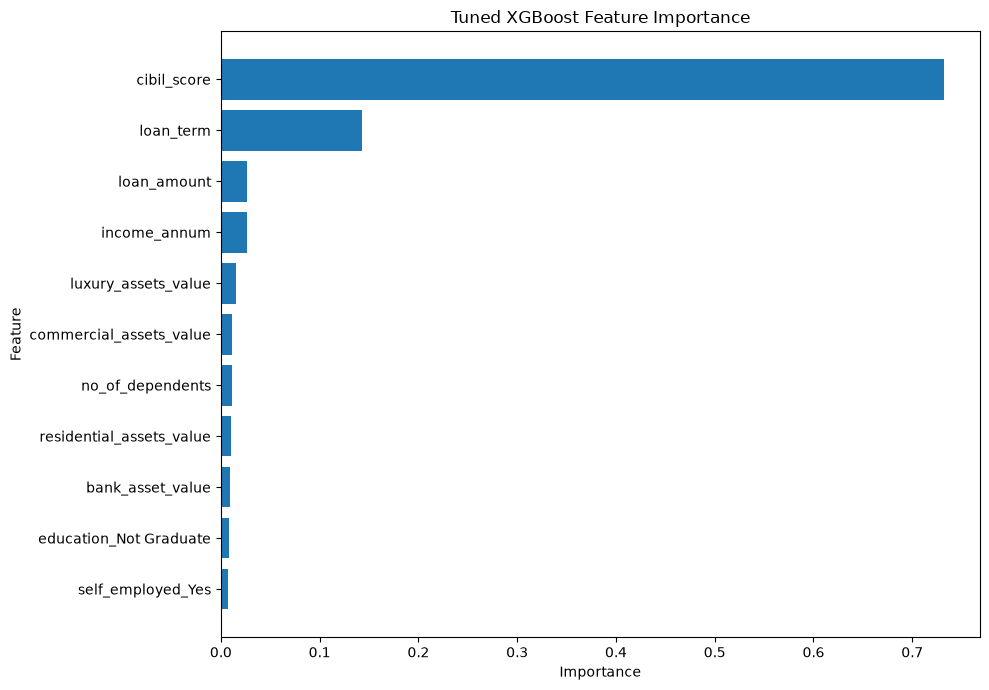

In [22]:
fitted_preprocessor = best_xgb_pipeline.named_steps[
    "preprocessor"
]
fitted_xgb_model = best_xgb_pipeline.named_steps["model"]

transformed_feature_names = (
    fitted_preprocessor.get_feature_names_out()
)

feature_importance_df = (
    pd.DataFrame({
        "feature": transformed_feature_names,
        "importance": fitted_xgb_model.feature_importances_,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(feature_importance_df)

plot_feature_importance = (
    feature_importance_df
    .head(15)
    .sort_values("importance", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(
    plot_feature_importance["feature"],
    plot_feature_importance["importance"],
)

ax.set_title("Tuned XGBoost Feature Importance")
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")

plt.tight_layout()
plt.show()

## Phase 13: Final Reusable XGBoost Training Function

The function below is the final experimental interface for the XGBoost model. It accepts the cleaned or raw dataset and exposes the main parameters that can be changed directly.

Editable parameters include:

- Test-set size.
- Random state.
- Number of estimators.
- Learning rate.
- Maximum tree depth.
- Minimum child weight.
- Row subsampling ratio.
- Feature subsampling ratio.
- Gamma.
- L1 regularization.
- L2 regularization.
- Classification threshold.

The function performs:

- Column and category whitespace cleaning.
- Identifier removal.
- Target encoding.
- Feature-type detection.
- Stratified splitting.
- Preprocessing pipeline construction.
- XGBoost training.
- Probability prediction.
- Threshold-based classification.
- Multi-metric evaluation.
- Return of the fitted pipeline and all key outputs.

Changing the function call is the recommended way to experiment with XGBoost parameters without rewriting the notebook workflow.

In [23]:
def train_xgboost_loan_model(
    data,
    target_column="loan_status",
    id_columns=("loan_id",),
    test_size=0.20,
    random_state=42,
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    min_child_weight=1.0,
    subsample=0.90,
    colsample_bytree=0.90,
    gamma=0.0,
    reg_alpha=0.0,
    reg_lambda=1.0,
    classification_threshold=0.50,
):
    working_data = data.copy()

    working_data.columns = (
        working_data.columns.str.strip()
    )

    object_columns = working_data.select_dtypes(
        include="object"
    ).columns

    for column in object_columns:
        working_data[column] = (
            working_data[column].str.strip()
        )

    if target_column not in working_data.columns:
        raise KeyError(
            f"Target column '{target_column}' was not found."
        )

    columns_to_drop = [
        column
        for column in id_columns
        if column in working_data.columns
    ]

    working_data = working_data.drop(
        columns=columns_to_drop
    )

    if working_data.isna().any().any():
        missing_columns = (
            working_data.columns[
                working_data.isna().any()
            ].tolist()
        )
        raise ValueError(
            "Missing values were detected in columns: "
            f"{missing_columns}"
        )

    target_mapping = {
        "Rejected": 0,
        "Approved": 1,
    }

    y_local = (
        working_data[target_column]
        .map(target_mapping)
    )

    if y_local.isna().any():
        unexpected_values = (
            working_data.loc[
                y_local.isna(),
                target_column,
            ]
            .unique()
            .tolist()
        )
        raise ValueError(
            "Unexpected target values were detected: "
            f"{unexpected_values}"
        )

    y_local = y_local.astype(int)

    X_local = working_data.drop(
        columns=[target_column]
    )

    numerical_local = (
        X_local
        .select_dtypes(include=np.number)
        .columns
        .tolist()
    )

    categorical_local = (
        X_local
        .select_dtypes(exclude=np.number)
        .columns
        .tolist()
    )

    local_preprocessor = ColumnTransformer(
        transformers=[
            (
                "numerical",
                StandardScaler(),
                numerical_local,
            ),
            (
                "categorical",
                OneHotEncoder(
                    drop="first",
                    handle_unknown="ignore",
                    sparse_output=False,
                ),
                categorical_local,
            ),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )

    X_train_local, X_test_local, y_train_local, y_test_local = (
        train_test_split(
            X_local,
            y_local,
            test_size=test_size,
            random_state=random_state,
            stratify=y_local,
        )
    )

    xgb_model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        max_depth=max_depth,
        min_child_weight=min_child_weight,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        gamma=gamma,
        reg_alpha=reg_alpha,
        reg_lambda=reg_lambda,
        random_state=random_state,
        n_jobs=-1,
    )

    model_pipeline = Pipeline(
        steps=[
            ("preprocessor", local_preprocessor),
            ("model", xgb_model),
        ]
    )

    start_time = time.perf_counter()
    model_pipeline.fit(
        X_train_local,
        y_train_local,
    )
    training_time = time.perf_counter() - start_time

    positive_probabilities = (
        model_pipeline.predict_proba(
            X_test_local
        )[:, 1]
    )

    predictions = (
        positive_probabilities
        >= classification_threshold
    ).astype(int)

    metrics = {
        "accuracy": accuracy_score(
            y_test_local,
            predictions,
        ),
        "precision": precision_score(
            y_test_local,
            predictions,
            zero_division=0,
        ),
        "recall": recall_score(
            y_test_local,
            predictions,
            zero_division=0,
        ),
        "f1_score": f1_score(
            y_test_local,
            predictions,
            zero_division=0,
        ),
        "roc_auc": roc_auc_score(
            y_test_local,
            positive_probabilities,
        ),
        "training_time_seconds": training_time,
        "classification_threshold":
            classification_threshold,
    }

    return {
        "pipeline": model_pipeline,
        "metrics": metrics,
        "X_train": X_train_local,
        "X_test": X_test_local,
        "y_train": y_train_local,
        "y_test": y_test_local,
        "predictions": predictions,
        "probabilities": positive_probabilities,
        "feature_columns": X_local.columns.tolist(),
        "numerical_features": numerical_local,
        "categorical_features": categorical_local,
    }

### Example Parameter Experiment

This cell demonstrates how to train a new XGBoost experiment by changing only the function arguments. Modify these values to compare model configurations.

Useful experimentation rules:

- Reduce `learning_rate` when increasing `n_estimators`.
- Avoid excessive `max_depth`, because deeper trees can overfit.
- Values below one for `subsample` and `colsample_bytree` can improve regularization.
- Increase `reg_alpha`, `reg_lambda`, or `gamma` when the model appears too complex.
- Change `classification_threshold` according to the desired approval precision-recall trade-off.

In [24]:
custom_xgb_experiment = train_xgboost_loan_model(
    data=df,
    n_estimators=250,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=1.0,
    subsample=0.90,
    colsample_bytree=0.90,
    gamma=0.0,
    reg_alpha=0.0,
    reg_lambda=1.0,
    classification_threshold=0.50,
)

display(
    pd.Series(
        custom_xgb_experiment["metrics"],
        name="Custom XGBoost Experiment",
    ).to_frame()
)

print(
    classification_report(
        custom_xgb_experiment["y_test"],
        custom_xgb_experiment["predictions"],
        target_names=["Rejected", "Approved"],
        digits=4,
    )
)

,Custom XGBoost Experiment
accuracy,0.9859
precision,0.9850
recall,0.9925
f1_score,0.9887
roc_auc,0.9987
training_time_seconds,0.8436
classification_threshold,0.5000


              precision    recall  f1-score   support

    Rejected     0.9875    0.9752    0.9813       323
    Approved     0.9850    0.9925    0.9887       531

    accuracy                         0.9859       854
   macro avg     0.9863    0.9838    0.9850       854
weighted avg     0.9860    0.9859    0.9859       854



## Phase 14: Model Serialization

The complete selected pipeline is serialized as one artifact. This is safer than saving preprocessing and the classifier separately because the feature transformations and model remain synchronized.

Additional metadata is saved for deployment and auditing:

- Target mapping.
- Selected model name.
- Input feature names.
- Evaluation results.

In [25]:
if Path.cwd().name == "notebooks":
    model_directory = Path("../models")
    report_directory = Path("../reports")
else:
    model_directory = Path("models")
    report_directory = Path("reports")

model_directory.mkdir(
    parents=True,
    exist_ok=True,
)
report_directory.mkdir(
    parents=True,
    exist_ok=True,
)

pipeline_path = (
    model_directory
    / "loan_approval_classification_pipeline.joblib"
)
metadata_path = (
    model_directory
    / "loan_approval_model_metadata.joblib"
)
comparison_report_path = (
    report_directory
    / "classification_model_comparison.csv"
)

model_metadata = {
    "target_column": target_column,
    "target_mapping": {
        "Rejected": 0,
        "Approved": 1,
    },
    "selected_model": best_comparison_row["model"],
    "input_features": X.columns.tolist(),
    "comparison_results":
        model_comparison_df.to_dict("records"),
}

joblib.dump(
    final_pipeline,
    pipeline_path,
)
joblib.dump(
    model_metadata,
    metadata_path,
)
model_comparison_df.to_csv(
    comparison_report_path,
    index=False,
)

print(
    f"Pipeline saved to: {pipeline_path.resolve()}"
)
print(
    f"Metadata saved to: {metadata_path.resolve()}"
)
print(
    "Model comparison report saved to: "
    f"{comparison_report_path.resolve()}"
)

Pipeline saved to: C:\Users\soham\Desktop\ahmed\NTI-ML\03_XGBoost_LoanApproval\models\loan_approval_classification_pipeline.joblib
Metadata saved to: C:\Users\soham\Desktop\ahmed\NTI-ML\03_XGBoost_LoanApproval\models\loan_approval_model_metadata.joblib
Model comparison report saved to: C:\Users\soham\Desktop\ahmed\NTI-ML\03_XGBoost_LoanApproval\reports\classification_model_comparison.csv


## Phase 15: Artifact Validation

The serialized pipeline is reloaded and used to reproduce predictions on the test set. This confirms that preprocessing and model inference remain valid after serialization.

In [26]:
reloaded_pipeline = joblib.load(pipeline_path)
reloaded_metadata = joblib.load(metadata_path)

reloaded_predictions = reloaded_pipeline.predict(X_test)

original_final_predictions = final_pipeline.predict(X_test)

if not np.array_equal(
    reloaded_predictions,
    original_final_predictions,
):
    raise ValueError(
        "Reloaded pipeline predictions do not match "
        "the original final pipeline predictions."
    )

print("Artifact validation completed successfully.")
print(
    f"Validated model: "
    f"{reloaded_metadata['selected_model']}"
)

Artifact validation completed successfully.
Validated model: Random Forest


## Final Conclusions

This notebook developed and evaluated an XGBoost model for loan approval classification and compared it with several widely used classification algorithms.

The final workflow provides:

- A cleaned and validated dataset.
- Reusable preprocessing through a `ColumnTransformer`.
- Leakage-safe model pipelines.
- Baseline and tuned XGBoost models.
- A multi-model comparison using consistent data splits and metrics.
- Threshold analysis.
- XGBoost feature importance.
- A reusable function for parameter experimentation.
- A serialized production pipeline and metadata artifact.

The highest metric score should not be the only deployment criterion. A financial institution should also consider model interpretability, stability, probability calibration, regulatory requirements, and the real cost of incorrect approval or rejection decisions.